In [27]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
df = pd.read_csv("cleaned_ebay_deals.csv",dtype=str)

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(by="timestamp")

In [12]:
print(df["timestamp"])

0    2026-03-10 16:20:33
1    2026-03-10 16:20:33
20   2026-03-10 16:20:34
19   2026-03-10 16:20:34
18   2026-03-10 16:20:34
             ...        
62   2026-03-10 16:20:37
58   2026-03-10 16:20:37
57   2026-03-10 16:20:37
59   2026-03-10 16:20:37
63   2026-03-10 16:20:38
Name: timestamp, Length: 64, dtype: datetime64[us]


In [13]:
df["hour"] = df["timestamp"].dt.hour
deals_per_hour = df.groupby("hour").size().reset_index(name="deal_count")

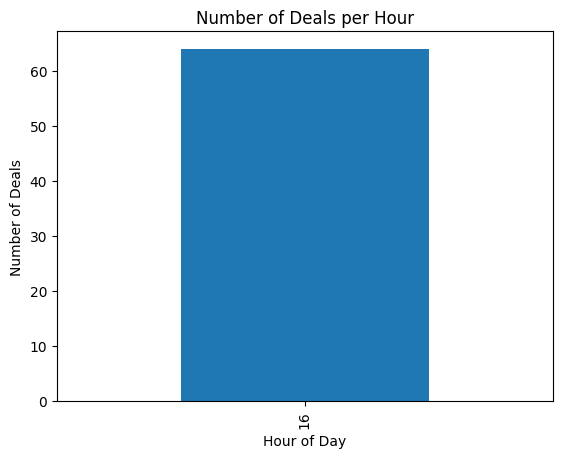

In [14]:
deals_per_hour.plot(kind="bar", x="hour", y="deal_count", legend=False)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Deals")
plt.title("Number of Deals per Hour")
plt.show()

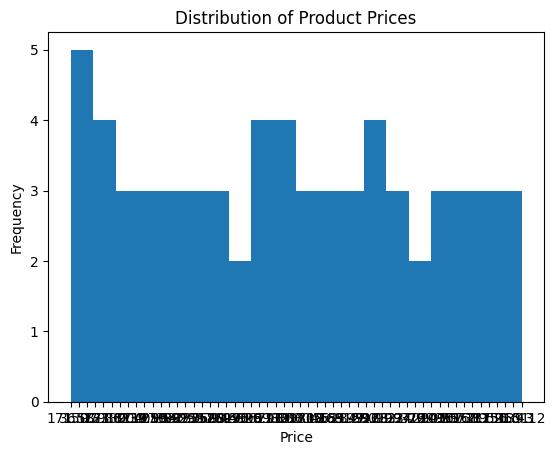

In [15]:
plt.figure()

plt.hist(df["price"], bins=20)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [18]:
df["price"] = pd.to_numeric(df["price"])
df["original_price"] = pd.to_numeric(df["original_price"])

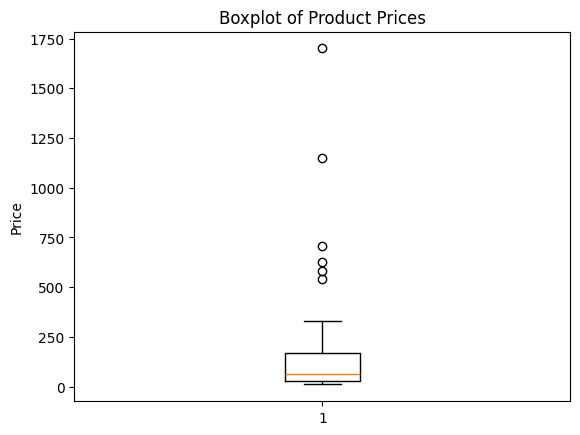

In [19]:
plt.figure()

plt.boxplot(df["price"])
plt.title("Boxplot of Product Prices")
plt.ylabel("Price")

plt.show()

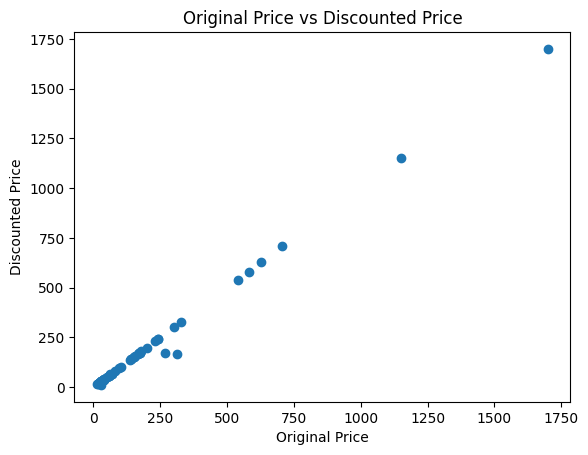

In [20]:
plt.figure()

plt.scatter(df["original_price"], df["price"])

plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.title("Original Price vs Discounted Price")

plt.show()

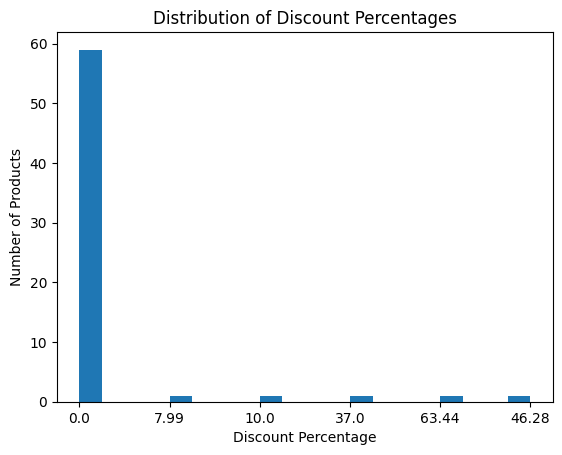

In [21]:
plt.figure()

plt.hist(df["discount_percentage"], bins=20)

plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.title("Distribution of Discount Percentages")

plt.show()

In [22]:
shipping_counts = df["shipping"].value_counts()

print(shipping_counts)

shipping
Shipping info unavailable    44
Free shipping                20
Name: count, dtype: int64


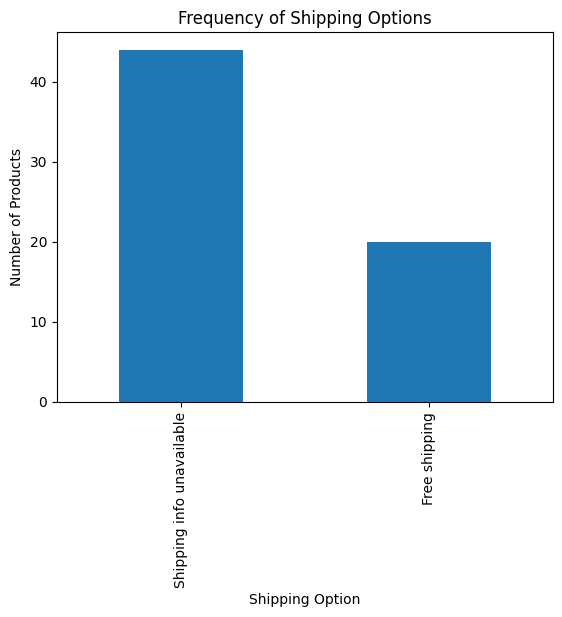

In [23]:
plt.figure()

shipping_counts.plot(kind="bar")

plt.xlabel("Shipping Option")
plt.ylabel("Number of Products")
plt.title("Frequency of Shipping Options")

plt.show()

In [26]:
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]
keyword_counts = {}

for word in keywords:
    count = df["title"].str.contains(word, case=False, na=False).sum()
    keyword_counts[word] = count

print(keyword_counts)

{'Apple': np.int64(4), 'Samsung': np.int64(0), 'Laptop': np.int64(2), 'iPhone': np.int64(3), 'Tablet': np.int64(1), 'Gimbal': np.int64(0)}


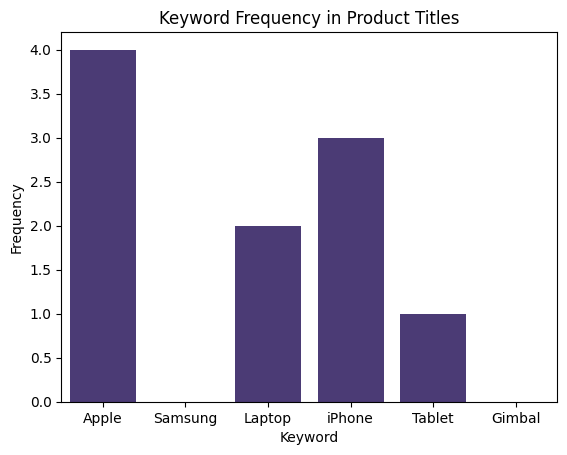

In [29]:
keyword_df = pd.DataFrame(list(keyword_counts.items()), columns=["keyword", "count"])
sns.set_palette("viridis")

plt.figure()

sns.barplot(data=keyword_df, x="keyword", y="count")

plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.title("Keyword Frequency in Product Titles")

plt.show()

In [30]:
df["absolute_discount"] = df["original_price"] - df["price"]

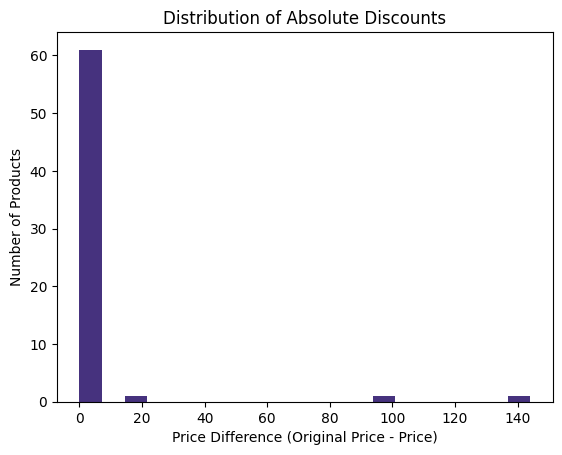

In [31]:
plt.figure()

plt.hist(df["absolute_discount"].dropna(), bins=20)

plt.xlabel("Price Difference (Original Price - Price)")
plt.ylabel("Number of Products")
plt.title("Distribution of Absolute Discounts")

plt.show()

In [32]:
top_deals = df.sort_values(by="discount_percentage", ascending=False)

top_5_deals = top_deals.head(5)

print(top_5_deals)

             timestamp                                              title  \
1  2026-03-10 16:20:33  Nokia 1209 - Midnight Blue (Unlocked) Cellular...   
49 2026-03-10 16:20:36  Married With Children ~ Complete 5th Fifth Sea...   
43 2026-03-10 16:20:36  CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...   
27 2026-03-10 16:20:35  12" Streaming Rear Camera Mirror with GPS Wifi...   
14 2026-03-10 16:20:34  New Genuine MR22GA AKB76039907 For LG Magic Bl...   

     price  original_price                   shipping  \
1    36.97           40.18              Free shipping   
49   10.95           29.95              Free shipping   
43  167.20          311.25  Shipping info unavailable   
27  169.47          269.00              Free shipping   
14   25.83           28.70              Free shipping   

                                                  url discount_percentage  \
1   https://www.ebay.com/itm/167612398310?_trkparm...                7.99   
49  https://www.ebay.com/itm/40669776308